In [1]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_groq import ChatGroq


c:\Users\ACER\OneDrive\Desktop\MACHINE LEARNING\Langraph\myvenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
llm_groq=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.9
)

In [3]:
class essaystate(TypedDict):
    essay_input:str
    language:str
    analysis:str
    structure:str
    originality:str
    final_evaluator:str

In [4]:
def check_language(state:essaystate)->essaystate:
    essay=state["essay_input"]
    
    prompt1=f"""Task: Evaluate only the LANGUAGE QUALITY.

Check:
- grammar
- clarity
- sentence flow
- readability
- vocabulary usage

Ignore argument quality, structure, and ideas.

Return only:

Language Score: X/10
Comments:
- point
- point
- point

Essay:
{essay}
"""
    
    response_language=llm_groq.invoke(prompt1)
    state["language"]=response_language
    
    return state

In [5]:
def check_depth(state:essaystate)->essaystate:
    essay=state["essay_input"]
    
    prompt2=f"""Task: Evaluate only the DEPTH OF ANALYSIS.

Check:
- multidimensional thinking
- reasoning
- use of examples
- understanding of topic

Penalize superficial description.

Ignore language quality and structure.

Return only:

Analysis Score: X/10
Comments:
- point
- point
- point

Essay:
{essay}
"""

    response_analysis=llm_groq.invoke(prompt2)
    state["analysis"]=response_analysis
    return state


In [6]:
def check_structure(state:essaystate)->essaystate:
    essay=state["essay_input"]
    prompt3=f"""Task: Evaluate only the STRUCTURE & COHERENCE.

Check:
- introduction
- logical flow
- transitions
- conclusion strength

Ignore grammar and ignore idea quality.

Return only:

Structure Score: X/10
Comments:
- point
- point
- point

Essay:
{essay}
"""

    response_structure=llm_groq.invoke(prompt3)
    state["structure"]=response_structure
    return state


In [7]:
def check_originality(state:essaystate)->essaystate:
    essay=state["essay_input"]
    prompt4=f"""Task: Evaluate only ORIGINALITY & CRITICAL THINKING.

Check:
- uniqueness of perspective
- balance of arguments
- counterarguments
- philosophical maturity

Penalize generic coaching-style content.

Ignore grammar and structure.

Return only:

Originality Score: X/10
Comments:
- point
- point
- point

Essay:
{essay}
"""

    response_originality=llm_groq.invoke(prompt4)
    state["originality"]=response_originality
    return state

In [8]:
def final_check(state:essaystate)->essaystate:
    prompt5=f"""IDENTITY: UPSC_HEAD_EXAMINER

You are the chief moderator of the UPSC essay evaluation board.

You do not evaluate essays directly.
You only moderate marks given by independent evaluators.

Your job:
- normalize marks
- remove extreme bias
- compute final score

Each section is equally weighted to 25 marks.
Convert scores from /10 to /25.

Do not re-read or judge the essay.
Use only the examiner reports.
Return only the requested format.


Combine the following examiner reports and produce final marks.

LANGUAGE:
{state["language"]}

ANALYSIS:
{state["analysis"]}

STRUCTURE:
{state["structure"]}

ORIGINALITY:
{state["originality"]}

Output:

Final Language Marks: X/25
Final Analysis Marks: X/25
Final Structure Marks: X/25
Final Originality Marks: X/25
Final Score: X/100

Performance Band:
Poor (0–40)
Average (41–60)
Good (61–75)
Very Good (76–90)
Topper Level (91–100)

Key Improvements:
- point
- point
- point
- point
- point

"""
 
    response_final_evaluator=llm_groq.invoke(prompt5)
    state["final_evaluator"]=response_final_evaluator
    return state

In [9]:
graph=StateGraph(essaystate)

graph.add_node("check_language",check_language)
graph.add_node("check_analysis",check_depth)
graph.add_node("check_structure",check_structure)
graph.add_node("check_originality",check_originality)

graph.add_edge(START,"check_language")
graph.add_edge("check_language","check_analysis")
graph.add_edge("check_analysis","check_structure")
graph.add_edge("check_structure","check_originality")
graph.add_node("final_check", final_check)
graph.add_edge("check_originality", "final_check")
graph.add_edge("final_check", END)


workflow=graph.compile()



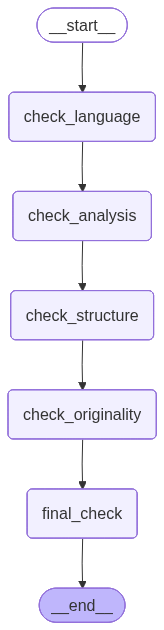

In [10]:
workflow

In [11]:
input_state={"essay_input":"""

Essay Topic: “Technology as the Silent Architect of Human Destiny”

Human history has often been narrated through kings, wars, and revolutions, yet beneath these visible events lies an invisible force quietly shaping civilizations — technology. From the discovery of fire to artificial intelligence, technology has not merely assisted human beings; it has redesigned the very way humans think, interact, govern, and even imagine their future. Thus, technology can be rightly described as the silent architect of human destiny.

In the earliest phase of human existence, survival depended entirely on nature. The invention of simple stone tools transformed human beings from passive creatures into active modifiers of their environment. The control of fire allowed warmth, protection, and cooking, which improved health and longevity. Agriculture, perhaps the first great technological revolution, settled nomadic populations and gave birth to villages, cities, and eventually states. Therefore, even ancient social organization was not primarily a political achievement but a technological consequence.

As societies evolved, technology continued to influence power structures. The invention of writing enabled administration and taxation, which strengthened empires such as those in Mesopotamia and India. The printing press democratized knowledge and weakened feudal hierarchies, contributing to the Renaissance and later the Enlightenment. It was not only new ideas that changed Europe; it was the ability to reproduce and distribute them widely. Thus, technological innovation often precedes intellectual and political transformation.

The Industrial Revolution further demonstrated technology’s decisive role. Steam engines and mechanized production shifted economies from agrarian to industrial. Urbanization followed, creating a new working class and prompting demands for labor rights, education, and democratic participation. Political ideologies like socialism and capitalism emerged as responses to industrial technology. Hence, economic and political systems were not independent developments but reactions to technological change.

In the contemporary era, digital technology has redefined human relationships. The internet has collapsed geographical barriers, enabling global communication in seconds. Social media platforms influence public opinion, elections, and even social movements. The Arab Spring, for instance, illustrated how digital networks can mobilize citizens rapidly. However, the same tools also spread misinformation and polarization. Thus, technology is neither inherently liberating nor oppressive; its impact depends on human values and governance.

Artificial intelligence now represents a new turning point. Machines are no longer limited to physical labor but increasingly perform cognitive tasks such as decision-making, pattern recognition, and language processing. This raises ethical concerns regarding privacy, employment, and autonomy. Automation may displace certain jobs while simultaneously creating new opportunities. The challenge before humanity is not technological advancement itself, but the absence of adequate ethical frameworks and regulatory institutions.

Technology has also deeply influenced culture and identity. Modern entertainment, online education, and digital economies have altered daily life patterns. Remote work changes family structures, while online learning expands access to education. Yet excessive dependence on technology can lead to isolation, mental health challenges, and erosion of interpersonal relationships. Therefore, technology shapes not only material conditions but also emotional and psychological experiences.

Environmental consequences further reveal technology’s dual character. Industrialization has improved living standards but also accelerated climate change and resource depletion. At the same time, green technologies such as renewable energy, electric mobility, and sustainable agriculture offer solutions. Humanity now faces a paradox: technology created many environmental problems, yet technology is also the most viable path to solving them.

The ethical dimension becomes crucial here. Technology itself is neutral; its application determines outcomes. Nuclear energy can generate electricity or destroy cities. Artificial intelligence can assist healthcare diagnostics or enable surveillance states. Therefore, human wisdom, democratic accountability, and moral responsibility must guide technological use. Without ethical direction, technological power may outpace social maturity.

For a country like India, technology offers transformative potential. Digital governance initiatives improve transparency, financial inclusion, and service delivery. Online education platforms expand opportunities for rural students. Telemedicine bridges healthcare gaps. However, the digital divide, data privacy concerns, and skill disparities must be addressed to ensure inclusive growth. Technology must empower citizens rather than deepen inequalities.

Ultimately, technology does not merely change tools; it changes human possibilities. It shapes how societies organize themselves, how economies function, and how individuals perceive reality. The future will not be determined solely by political leaders or economic policies but by how humanity chooses to integrate technology with ethics, equity, and sustainability.

In conclusion, technology is indeed the silent architect of human destiny. It quietly constructs the frameworks within which civilizations rise, values evolve, and futures unfold. Yet the architect does not decide the purpose of the building — humanity does. If guided by wisdom and compassion, technology can enable human flourishing. If guided only by profit and power, it may magnify inequality and conflict. Therefore, the true task before humankind is not to control technology alone, but to develop the moral vision necessary to use it responsibly."""}

In [12]:
output_state=workflow.invoke(input_state)
output_state

{'essay_input': '\n\nEssay Topic: “Technology as the Silent Architect of Human Destiny”\n\nHuman history has often been narrated through kings, wars, and revolutions, yet beneath these visible events lies an invisible force quietly shaping civilizations — technology. From the discovery of fire to artificial intelligence, technology has not merely assisted human beings; it has redesigned the very way humans think, interact, govern, and even imagine their future. Thus, technology can be rightly described as the silent architect of human destiny.\n\nIn the earliest phase of human existence, survival depended entirely on nature. The invention of simple stone tools transformed human beings from passive creatures into active modifiers of their environment. The control of fire allowed warmth, protection, and cooking, which improved health and longevity. Agriculture, perhaps the first great technological revolution, settled nomadic populations and gave birth to villages, cities, and eventually